# 04 — Report: build every chart/metric for the paper from results/run2/

Reads each ablation's full per-row checkpoint (not just `metrics_summary.json`) to build: accuracy+MAE bar, per-class F1, confusion matrices, dissonance distribution, error recovery (text_only → full_graph), per-sample predictions (first 50 rows), per-rating latency, and a faithfulness/avg-reflection-edges summary. Mirrors `results/run1/`'s chart set (see `CLAUDE.md`). Skips Spatial IoU per mission spec §5.5 — no patch-level visual grounding here (BLIP captioning, not true detection).

In [1]:
%cd /content
!rm -rf /content/repo
!git clone https://github.com/kvarun314/pes-mtech-project.git /content/repo
%cd /content/repo
%pip install -q -e .
import sys
sys.path.insert(0, "/content/repo/src")  # editable-install .pth is only read at
# interpreter startup, not picked up by an already-running kernel -- insert the
# path directly so the import below works without a runtime restart.
import agentic_sentiment
print("agentic_sentiment importable:", agentic_sentiment.__file__)

/content
Cloning into '/content/repo'...
remote: Enumerating objects: 744, done.
remote: Counting objects: 100% (744/744), done.
remote: Compressing objects: 100% (378/378), done.
remote: Total 744 (delta 409), reused 640 (delta 318), pack-reused 0 (from 0)
Receiving objects: 100% (744/744), 8.13 MiB | 14.38 MiB/s, done.
Resolving deltas: 100% (409/409), done.
/content/repo
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.4/71.4 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 406.8/406.8 kB 24.4 MB/s eta 0:00:00
  Building editable for agentic-sentiment (pyproject.toml) ... done
agentic_sentiment importable: /content/repo/src/agentic_sentiment/__init__.py


In [2]:
from google.colab import drive
drive.mount("/content/drive")
RESULTS_DIR = "/content/drive/MyDrive/pes-mtech-project/results/run2"

Mounted at /content/drive


In [3]:
import json
import os

from agentic_sentiment.eval.checkpoint import read_records
from agentic_sentiment.eval.run_eval import ABLATIONS

with open(f"{RESULTS_DIR}/metrics_summary.json") as f:
    metrics = json.load(f)

# Every ablation's full per-row checkpoint, not just the slim accuracy/F1/MAE
# summary -- this is what lets every chart below use real per-row data
# (dissonance, correction_iters, rag_grounding, latency_s) instead of being
# limited to whatever compute_metrics() already aggregated.
records_by_ablation = {
    name: read_records(f"{RESULTS_DIR}/{name}_checkpoint.jsonl")
    for name in ABLATIONS
    if name != "plus_rag_specs"  # notebook 03 never writes this file -- aliased from full_graph
}
records_by_ablation["plus_rag_specs"] = records_by_ablation["full_graph"]

_dissonance_path = f"{RESULTS_DIR}/dissonance_ablation_metrics.json"
dissonance_metrics = json.load(open(_dissonance_path)) if os.path.exists(_dissonance_path) else None

print({name: len(recs) for name, recs in records_by_ablation.items()})

{'text_only': 2000, 'plus_metadata': 2000, 'plus_image': 2000, 'plus_rag_reviews': 2000, 'full_graph': 2000, 'plus_rag_specs': 2000}


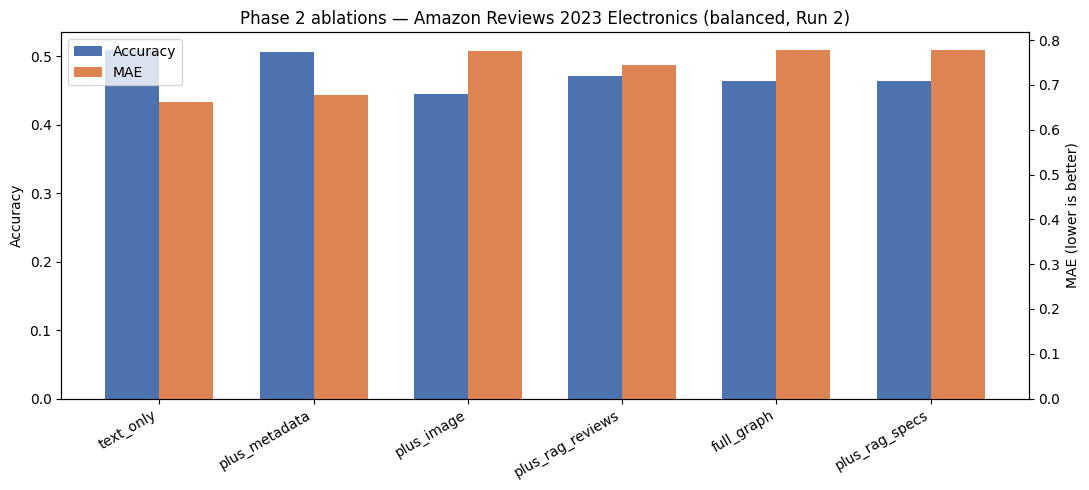

In [4]:
import matplotlib.pyplot as plt
import numpy as np

names = list(metrics.keys())
accs = [metrics[n]["accuracy"] for n in names]
maes = [metrics[n]["mae"] for n in names]

fig, ax1 = plt.subplots(figsize=(11, 5))
x = np.arange(len(names))
width = 0.35
ax1.bar(x - width / 2, accs, width, label="Accuracy", color="#4C72B0")
ax1.set_ylabel("Accuracy")
ax2 = ax1.twinx()
ax2.bar(x + width / 2, maes, width, label="MAE", color="#DD8452")
ax2.set_ylabel("MAE (lower is better)")
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=30, ha="right")
ax1.set_title("Phase 2 ablations — Amazon Reviews 2023 Electronics (balanced, Run 2)")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/metrics_comparison.png", dpi=150)
plt.show()

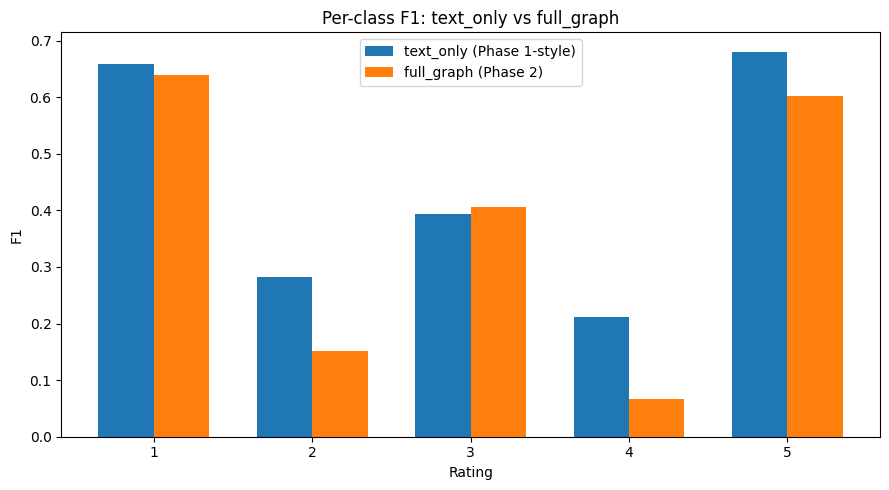

In [5]:
from sklearn.metrics import f1_score


def per_class_f1(records):
    gt = [r["gt_rating"] for r in records]
    pred = [r["final_rating"] for r in records]
    return f1_score(gt, pred, labels=[1, 2, 3, 4, 5], average=None, zero_division=0)


f1_text_only = per_class_f1(records_by_ablation["text_only"])
f1_full_graph = per_class_f1(records_by_ablation["full_graph"])

x = np.arange(5)
width = 0.35
plt.figure(figsize=(9, 5))
plt.bar(x - width / 2, f1_text_only, width, label="text_only (Phase 1-style)")
plt.bar(x + width / 2, f1_full_graph, width, label="full_graph (Phase 2)")
plt.xticks(x, [1, 2, 3, 4, 5])
plt.xlabel("Rating")
plt.ylabel("F1")
plt.title("Per-class F1: text_only vs full_graph")
plt.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/per_class_f1.png", dpi=150)
plt.show()

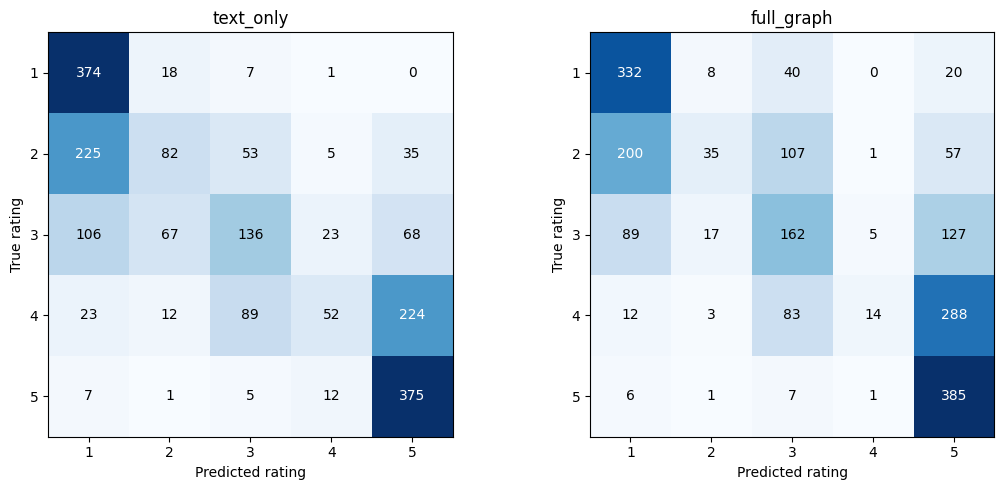

In [6]:
from agentic_sentiment.eval.run_eval import compute_metrics

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, name in zip(axes, ["text_only", "full_graph"]):
    cm = compute_metrics(records_by_ablation[name])["confusion"]
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xlabel("Predicted rating")
    ax.set_ylabel("True rating")
    ax.set_xticks(range(5)); ax.set_xticklabels([1, 2, 3, 4, 5])
    ax.set_yticks(range(5)); ax.set_yticklabels([1, 2, 3, 4, 5])
    vmax = max(max(row) for row in cm) or 1
    for i in range(5):
        for j in range(5):
            ax.text(j, i, cm[i][j], ha="center", va="center",
                     color="white" if cm[i][j] > vmax / 2 else "black")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/confusion_matrices.png", dpi=150)
plt.show()

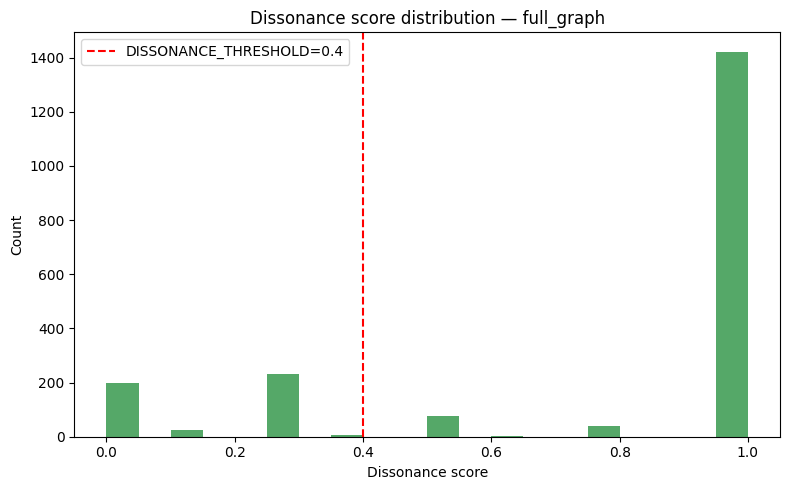

norm vs stdev dissonance ablation: {'norm': {'accuracy': 0.464, 'macro_f1': 0.3729858050223741, 'mae': 0.7785, 'confusion': [[332, 8, 40, 0, 20], [200, 35, 107, 1, 57], [89, 17, 162, 5, 127], [12, 3, 83, 14, 288], [6, 1, 7, 1, 385]], 'n': 2000}, 'stdev': {}}


In [7]:
from agentic_sentiment.agents.critic import DISSONANCE_THRESHOLD

dissonance_values = [r["dissonance"] for r in records_by_ablation["full_graph"] if r.get("dissonance") is not None]
plt.figure(figsize=(8, 5))
plt.hist(dissonance_values, bins=20, color="#55A868")
plt.axvline(DISSONANCE_THRESHOLD, color="red", linestyle="--", label=f"DISSONANCE_THRESHOLD={DISSONANCE_THRESHOLD}")
plt.xlabel("Dissonance score")
plt.ylabel("Count")
plt.title("Dissonance score distribution — full_graph")
plt.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/dissonance_analysis.png", dpi=150)
plt.show()

if dissonance_metrics:
    print("norm vs stdev dissonance ablation:", dissonance_metrics)
else:
    print("dissonance_ablation_metrics.json not found -- cell 16 of notebook 03 may not have run.")

Error recovery (text_only -> full_graph): {'fixed': 110, 'regressed': 201, 'net': -91}


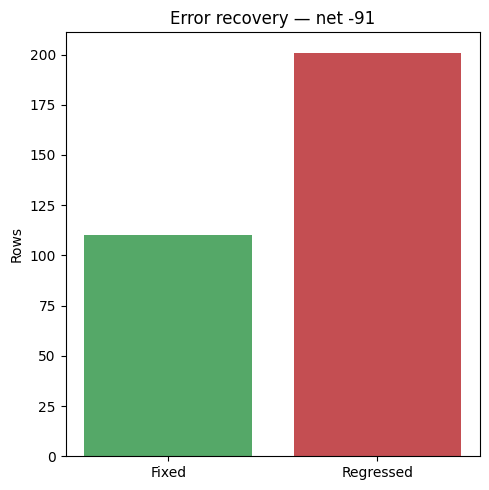

In [8]:
from agentic_sentiment.eval.run_eval import error_recovery

recovery = error_recovery(records_by_ablation["text_only"], records_by_ablation["full_graph"])
print("Error recovery (text_only -> full_graph):", recovery)

plt.figure(figsize=(5, 5))
plt.bar(["Fixed", "Regressed"], [recovery["fixed"], recovery["regressed"]], color=["#55A868", "#C44E52"])
plt.ylabel("Rows")
plt.title(f"Error recovery — net {recovery['net']:+d}")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/error_recovery.png", dpi=150)
plt.show()

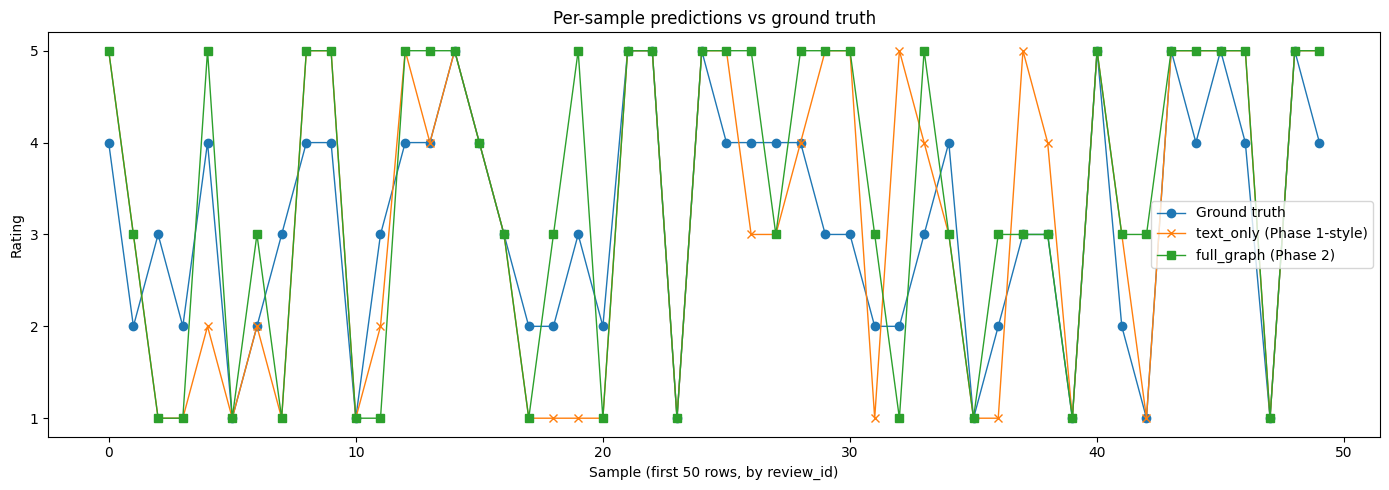

In [9]:
text_only_by_id = {r["review_id"]: r for r in records_by_ablation["text_only"]}
full_graph_by_id = {r["review_id"]: r for r in records_by_ablation["full_graph"]}
# Matched by review_id, not row order -- a resumed checkpoint can interleave
# rows in a different order than the original run.
common_ids = sorted(set(text_only_by_id) & set(full_graph_by_id))[:50]

gts = [text_only_by_id[i]["gt_rating"] for i in common_ids]
p1 = [text_only_by_id[i]["final_rating"] for i in common_ids]
p2 = [full_graph_by_id[i]["final_rating"] for i in common_ids]

plt.figure(figsize=(14, 5))
plt.plot(gts, label="Ground truth", marker="o", linewidth=1)
plt.plot(p1, label="text_only (Phase 1-style)", marker="x", linewidth=1)
plt.plot(p2, label="full_graph (Phase 2)", marker="s", linewidth=1)
plt.xlabel("Sample (first 50 rows, by review_id)")
plt.ylabel("Rating")
plt.yticks([1, 2, 3, 4, 5])
plt.legend()
plt.title("Per-sample predictions vs ground truth")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/per_sample_predictions.png", dpi=150)
plt.show()

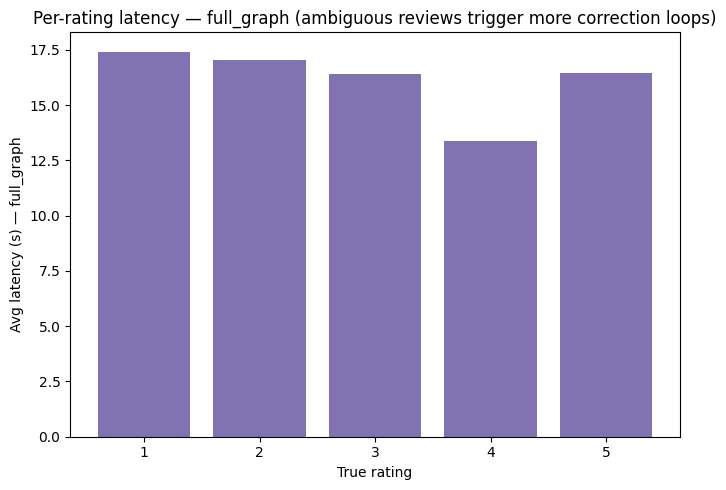

In [10]:
from collections import defaultdict

latency_by_rating = defaultdict(list)
for r in records_by_ablation["full_graph"]:
    if r.get("latency_s") is not None:
        latency_by_rating[r["gt_rating"]].append(r["latency_s"])

ratings = sorted(latency_by_rating)
avg_latency_by_rating = [sum(latency_by_rating[r]) / len(latency_by_rating[r]) for r in ratings]
plt.figure(figsize=(7, 5))
plt.bar([str(r) for r in ratings], avg_latency_by_rating, color="#8172B2")
plt.xlabel("True rating")
plt.ylabel("Avg latency (s) — full_graph")
plt.title("Per-rating latency — full_graph (ambiguous reviews trigger more correction loops)")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/per_rating_latency.png", dpi=150)
plt.show()

In [11]:
from agentic_sentiment.eval.run_eval import average_correction_iters, average_grounding, average_latency

# faithfulness (mission spec §14) = mean rag_grounding across rows where RAG
# ran; None for ablations that never enabled RAG (text_only/plus_metadata/
# plus_image). average reflection edges per input = avg correction_iters.
report_summary = {
    name: {
        "faithfulness": average_grounding(recs),
        "avg_correction_iters": average_correction_iters(recs),
        "avg_latency_s": average_latency(recs),
    }
    for name, recs in records_by_ablation.items()
}
print(json.dumps(report_summary, indent=2))

with open(f"{RESULTS_DIR}/report_summary.json", "w") as f:
    json.dump(report_summary, f, indent=2)

{
  "text_only": {
    "faithfulness": null,
    "avg_correction_iters": 0.0,
    "avg_latency_s": 0.3109736194210009
  },
  "plus_metadata": {
    "faithfulness": null,
    "avg_correction_iters": 0.0,
    "avg_latency_s": 0.45202084472899606
  },
  "plus_image": {
    "faithfulness": null,
    "avg_correction_iters": 0.393,
    "avg_latency_s": 1.0885382821250085
  },
  "plus_rag_reviews": {
    "faithfulness": null,
    "avg_correction_iters": 0.608,
    "avg_latency_s": 1.8882310466214822
  },
  "full_graph": {
    "faithfulness": 0.2905,
    "avg_correction_iters": 1.5595,
    "avg_latency_s": 16.138694088328034
  },
  "plus_rag_specs": {
    "faithfulness": 0.2905,
    "avg_correction_iters": 1.5595,
    "avg_latency_s": 16.138694088328034
  }
}


In [12]:
import os
import shutil

from agentic_sentiment.colab_sync import push_repo_changes

repo_results_dir = "/content/repo/results/run2"
os.makedirs(repo_results_dir, exist_ok=True)

_REPORT_FILES = [
    "metrics_comparison.png", "per_class_f1.png", "confusion_matrices.png",
    "dissonance_analysis.png", "error_recovery.png", "per_sample_predictions.png",
    "per_rating_latency.png", "report_summary.json",
]
copied = []
for name in _REPORT_FILES:
    src = f"{RESULTS_DIR}/{name}"
    if os.path.exists(src):
        shutil.copy2(src, f"{repo_results_dir}/{name}")
        copied.append(name)
    else:
        print("WARNING: missing", src, "-- a cell above may not have run yet; "
              "check output before this cell before re-running.")
print(f"Copied {len(copied)}/{len(_REPORT_FILES)} file(s):", copied)

try:
    from google.colab import userdata
    github_token = userdata.get("GITHUB_TOKEN")
# A missing GITHUB_TOKEN is fine -- this step is optional documentation.
except Exception:
    github_token = os.environ.get("GITHUB_TOKEN", "")

if not github_token:
    print("GITHUB_TOKEN not set -- download", repo_results_dir, "and commit these yourself.")
else:
    print(push_repo_changes(
        repo_dir="/content/repo", paths=[f"results/run2/{name}" for name in copied],
        message="Add Run 2 report charts + summary", token=github_token,
    ))

Copied 8/8 file(s): ['metrics_comparison.png', 'per_class_f1.png', 'confusion_matrices.png', 'dissonance_analysis.png', 'error_recovery.png', 'per_sample_predictions.png', 'per_rating_latency.png', 'report_summary.json']
Pushed 8 path(s) to main: Add Run 2 report charts + summary
